In [ ]:
import torch
import numpy as np
import cv2
import os
from PIL import Image
from diffusers import StableDiffusionImg2ImgPipeline
from IPython.display import display


REFERENCE_BANK = {
    "Platax teira": "references/platax_teira.png",
    "Human divers": "references/diver.png",
    "Reefs and invertebrates": "references/coral.png",
    "Shark": "references/shark.png",
    "Siganus vulpinus": "references/siganus_vulpinus.png",
    "Pagrus auratus": "references/pagrus_auratus.png",
    "Carcharhinus limbatus": "Carcharhinus_limbatus.png"

}

def generate_full_scene_cgi_hybrid(compressed_data):
    print("\nHybrid placeme,nt")

    max_x = 640
    max_y = 480



    bg_color_bgr = (100, 70, 20)

    if 'Background' in compressed_data:
        bg_rgb = compressed_data['Background'].get('average_real_color', [20, 70, 100])
        bg_color_bgr = (int(bg_rgb[2]), int(bg_rgb[1]), int(bg_rgb[0]))
        print(f" RGB{tuple(bg_rgb)}")


    canvas = np.full((max_y, max_x, 3), bg_color_bgr, dtype=np.uint8)

    for obj_name, obj_info in compressed_data.items():

        if obj_name == 'Background' or obj_info.get('species') == 'Background':
            continue

        classe = obj_info.get('species', 'Unknown')
        color_rgb = obj_info.get('average_real_color', obj_info.get('rgb_color', [128, 128, 128]))
        color_bgr = (int(color_rgb[2]), int(color_rgb[1]), int(color_rgb[0]))

        for contour_name, contour_info in obj_info.get('contours', {}).items():
            if not contour_info: continue

            N = contour_info['original_length']
            coeffs = contour_info['coeffs']

            if len(coeffs) == N:
                reconstructed_coeffs = np.array(coeffs)
            else:
                num_keep = len(coeffs) // 2
                reconstructed_coeffs = np.zeros(N, dtype=complex)
                reconstructed_coeffs[:num_keep] = coeffs[:num_keep]
                reconstructed_coeffs[-num_keep:] = coeffs[-num_keep:]

            reconstructed_complex = np.fft.ifft(reconstructed_coeffs)
            points = np.column_stack((np.real(reconstructed_complex), np.imag(reconstructed_complex)))
            points = np.int32(points)

            if len(points) == 0: continue

            # PHybrid placement
            ref_path = REFERENCE_BANK.get(classe)

            if ref_path and os.path.exists(ref_path):
                x, y, w, h = cv2.boundingRect(points)
                if x < 0 or y < 0 or x+w > max_x or y+h > max_y or w == 0 or h == 0:
                    cv2.fillPoly(canvas, [points], color_bgr)
                    continue

                ref_img = cv2.imread(ref_path, cv2.IMREAD_UNCHANGED)
                if ref_img is None or ref_img.shape[2] != 4:
                    cv2.fillPoly(canvas, [points], color_bgr)
                    continue

                ref_resized = cv2.resize(ref_img, (w, h))
                ref_bgr = ref_resized[:, :, :3]
                ref_alpha = ref_resized[:, :, 3] / 255.0

                object_mask = np.zeros((max_y, max_x), dtype=np.uint8)
                cv2.fillPoly(object_mask, [points], 1)
                local_mask = object_mask[y:y+h, x:x+w]

                final_alpha = ref_alpha * local_mask

                roi = canvas[y:y+h, x:x+w]
                for c in range(3):
                    roi[:, :, c] = (final_alpha * ref_bgr[:, :, c] + (1 - final_alpha) * roi[:, :, c])
                canvas[y:y+h, x:x+w] = roi
            else:
                cv2.fillPoly(canvas, [points], color_bgr)

    canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
    init_image = Image.fromarray(canvas_rgb).resize((768, 512))

    display(init_image)

    print("\nStable diffusion v1.5")

    prompt = "A masterpiece photorealistic underwater photography, cinematic underwater lighting, volumetric caustics, deep blue ocean, national geographic 8k"


    negative_prompt = "cartoon, drawing, geometric lines, 2d, bad anatomy, collage, copy paste"

    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16,
        safety_checker=None
    ).to("cuda")

    print("\nHarmonization")

    image_generee = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=init_image,
        strength=0.50,
        guidance_scale=7.5,
        num_inference_steps=50
    ).images[0]

    display(image_generee)
    image_generee.save("finalee_image.png")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.



[1/4] Décompression géométrique et Placement CGI...
 -> Océan ambiant détecté : RGB(56, 66, 162)

[2/4] Collage CGI (Textures réelles sur le fond calculé) :


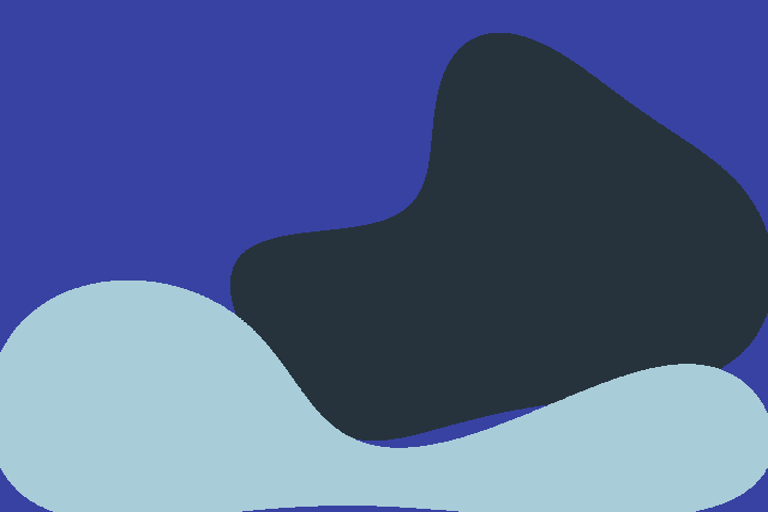


[3/4] Chargement de Stable Diffusion (Mode Fusion de lumières)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

text_encoder/config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



[4/4] Harmonisation de la scène par l'IA...


  0%|          | 0/25 [00:00<?, ?it/s]


🎉 Scène Finale Reconstruite et Harmonisés :


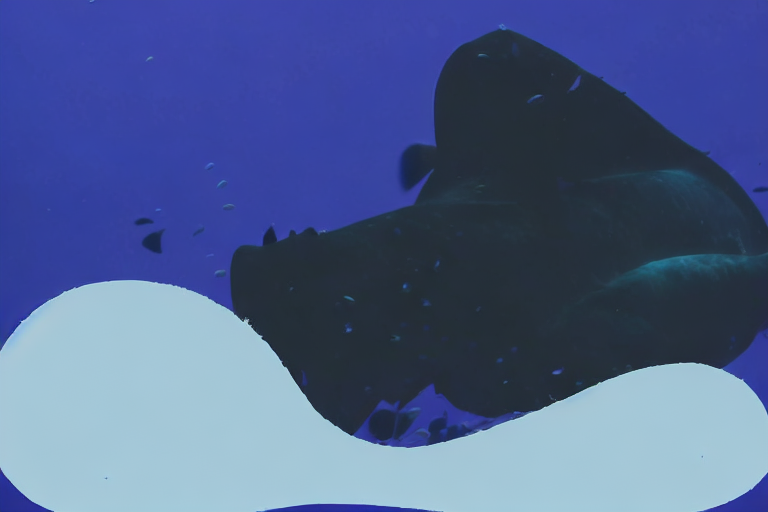

In [ ]:
compressed_data = {XXXXXXXXXXXX}
generate_full_scene_cgi_hybrid(compressed_data)